In [3]:
import tensorflow as tf
import numpy as np
import re
import os

# Function to read and parse the tensor data from a text file
def parse_tensor_from_file(file_path, shape):
    with open(file_path, 'r') as file:
        # Read the content of the file
        tensor_str = file.read()
    components = re.findall(r"([+-]?\d+\.?\d*[eE]?[+-]?\d*(?:\s*[+-]?\d*\.?\d*[eE]?[+-]?\d*j)?)", tensor_str)

    # Convert the components into a numpy array of complex numbers
    complex_numbers = [complex(c.replace(' ','')) for c in components]

    # Convert the list to a NumPy array and reshape it
    numpy_tensor = np.array(complex_numbers, dtype=np.complex128)

    if (shape == 3):
        numpy_tensor = numpy_tensor.reshape(round(numpy_tensor.size ** (1/shape)),round(numpy_tensor.size ** (1/shape)),round(numpy_tensor.size ** (1/shape)))
    if (shape == 2):
        size = numpy_tensor.size
        new_shape = (round(size ** (1/shape)), round(size ** (1/shape))) if shape == 2 else (size,)
        numpy_tensor = numpy_tensor.reshape(new_shape)
    # Convert NumPy array to TensorFlow tensor
    tf_tensor = tf.convert_to_tensor(numpy_tensor)

    return tf_tensor
def retrieve_X_dict(base_dir):
     # Iterate through each subfolder in the base directory
     X_dict = {}

     # Iterate through each subfolder in the base directory
     directories = os.listdir(base_dir)
     folder_names = [item for item in directories if os.path.isdir(os.path.join(base_dir, item))]
     # Sort folders numerically or lexicographically
     folder_names.sort(key=lambda x: (x.split('_')[2]))

     for folder_name in folder_names:
        folder_path = os.path.join(base_dir, folder_name)
        if os.path.isdir(folder_path):
          # Path to the cost.txt file
          
          parts = folder_path.split('_')  # Split by underscore
          postfix = parts[-1]  # Get the last part
          
          rho2_file_path = os.path.join(folder_path, 'tr_rho2.txt')
          out_rho2_file_path = os.path.join(folder_path, 'tr_out_rho2.txt')
          if not os.path.exists(rho2_file_path):
              continue
          #print(rho2_file_path, out_rho2_file_path)
          with open(rho2_file_path, 'r') as file:
                tensor = parse_tensor_from_file(rho2_file_path, 1)
                # Convert the extracted string to a complex number
                for t in tensor.numpy():
                    # Get the real part and convert to float
                    num_rho2 = t.real

          with open(out_rho2_file_path, 'r') as file:
                tensor = parse_tensor_from_file(out_rho2_file_path, 1)
                # Convert the extracted string to a complex number
                for t in tensor.numpy():
                    # Get the real part and convert to float
                    num_out_rho2 = t.real

          if "$\\rho'$"+" ("+postfix+")" not in X_dict:
               X_dict["$\\rho'$"+" ("+postfix+")"] = []
          if "$\\overline{\\rho'}$"+" ("+postfix+")" not in X_dict:
               X_dict["$\\overline{\\rho'}$"+" ("+postfix+")"] = []     
          X_dict["$\\rho'$"+" ("+postfix+")"].append((num_rho2))
          X_dict["$\\overline{\\rho'}$"+" ("+postfix+")"].append((num_out_rho2))
     return X_dict


I0000 00:00:1748838364.002023 2217391 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46849 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:68:00.0, compute capability: 8.6


{"$\\rho'$ (b)": [np.float64(0.08324902), np.float64(0.08316412400491363), np.float64(0.08290995511991199), np.float64(0.08248806535925968), np.float64(0.08190102386702683), np.float64(0.08115239085977942), np.float64(0.08024668166590634), np.float64(0.07918932136974477), np.float64(0.07798659069785818), np.float64(0.0766455639025053), np.float64(0.0751740395014903), np.float64(0.07358046482247227), np.float64(0.0718738553720358), np.float64(0.07006371010434366), np.float64(0.0681599237003377), np.float64(0.06617269698594402), np.float64(0.06411244661666538), np.float64(0.06198971513678131), np.float64(0.059815082484937804), np.float64(0.05759907996534099), np.float64(0.05535210763650519), np.float64(0.05308435598922701), np.float64(0.050805732694052565), np.float64(0.04852579509801752), np.float64(0.04625368904301827), np.float64(0.043998094466022736), np.float64(0.04176717812665549), np.float64(0.03956855369266257), np.float64(0.03740924930044444), np.float64(0.03529568259818858), np

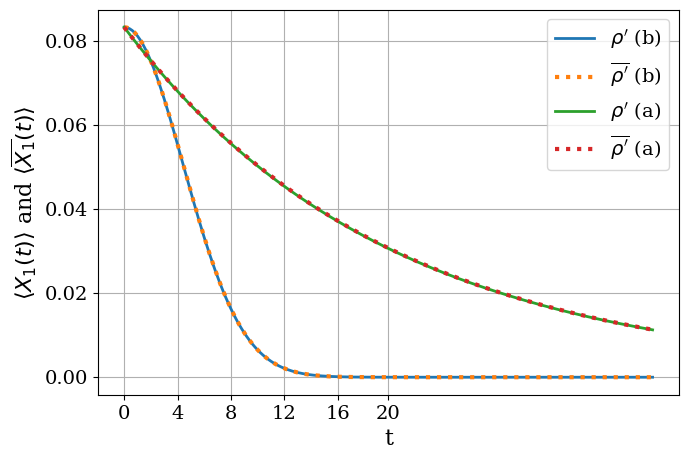

In [4]:
import matplotlib.pyplot as plt

def plot_dict (fidelity_dict, xlabel, ylabel, file_name, max, step, maxNum):
    # Plotting
    plt.rc('font', family='serif')
    plt.figure(figsize=(7.5, 5))

    # Plot each category
    i = 0
    for key, values in fidelity_dict.items():
        x = np.arange(len(values))  # Generate x-values
        if "overline" in key.lower():
            # Plot as lines for other keys
            plt.plot(
                x, values, label=key, linestyle='dotted', alpha=1, linewidth=3
            )
        else:
            # Plot as dots for keys containing 'unitary'
            plt.plot(
                x, values, label=key, linestyle='solid', alpha=1, linewidth=2
            )
            

    # Adding title and labels
    plt.xlabel(xlabel, fontsize=16)
    plt.ylabel(ylabel, fontsize=16)
    #plt.yscale('log')  # Set y-axis to logarithmic scale
    # Customizing x-axis ticks
    x_ticks = np.arange(0, max, step=step)  # Adjust step size based on your data
    if max-1 not in x_ticks:
        x_ticks = np.append(x_ticks, max-1)
    x_tick_labels = [f'{tick/(max-1)*maxNum:.0f}' for tick in x_ticks]  # Convert to float and format
    
    plt.xticks(ticks=x_ticks, labels=x_tick_labels)
    plt.xticks(fontsize=14) 
    plt.yticks(fontsize=14) 
    plt.grid(True)
    plt.legend(fontsize=14)
    
    # plt.savefig(f'../../docs/new_fig/{file_name}.png', format='png',  bbox_inches='tight')
    # plt.savefig(f'../../docs/new_fig/{file_name}.eps', format='eps',  bbox_inches='tight')
    

    # Display the plot
    plt.show()


trace_dict = retrieve_X_dict('../../results/experiment_result_X')
print (trace_dict)
plot_dict(fidelity_dict=trace_dict, xlabel='t', ylabel="$\\langle X_1(t)\\rangle$ and $\\langle \\overline{X_1}(t)\\rangle$", file_name="trace_X", max=100, step=20, maxNum=20)